# Problem Satement:
Retailers face challenges such as:
- Overstocking or stockouts leading to lost revenue
- Inefficient inventory management increasing costs
- Missed opportunities during seasonal demand peaks.

 This project builds a machine learning solution to:
- Forecast product sales based on pricing, promotions, customer demographics, and seasonality
- Identify key drivers of demand (e.g., discounts, holidays, customer segments)
- Provide actionable insights for inventory planning, pricing strategy, and marketing campaigns
By leveraging transaction and customer data, the model enables retailers to optimize stock levels, reduce costs, and maximize revenue growth.



# 1.Import Required Libraries

In [3]:
#Import Required Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [4]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Preprocessing
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,GridSearchCV

In [6]:
#Models And Metrics
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

# 2.Load The Dataset


In [7]:
df=pd.read_csv('/content/synthetic_retail_sales_final3.csv')

In [8]:
df.head()

,Transaction_ID,Product_ID,Category,Price,Discount,Promotion_Flag,Customer_Age,Gender,Region,Month,...,Return_Flag,Shipping_Cost,Stock_Availability,Season,Customer_Income,Review_Score,Units_Sold,Loyalty_Points,Revenue,Profit
0,T100000,P1000,Clothing,35.95,11.60,1,69.0,Female,North,5,...,0,19.09,0,Spring,67086.0,2.0,258,25,6282.30,1256.46
1,T100001,P1001,Sports,10.24,2.33,1,68.0,Male,East,1,...,0,0.46,0,Summer,84225.0,NaN,240,24,1898.40,189.84
2,T100002,P1002,Grocery,40.91,47.26,0,21.0,Male,North,9,...,0,41.01,0,Summer,118827.0,2.0,327,32,-2076.45,-103.82
3,T100003,P1003,Grocery,103.49,15.69,1,31.0,Male,North,2,...,0,8.46,0,Winter,122490.0,5.0,343,34,30115.40,1505.77
4,T100004,P1004,Electronics,79.55,22.13,1,46.0,Male,North,7,...,0,35.90,0,Winter,NaN,1.0,329,32,18891.18,4722.80


#3.Basic Datacheck

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         5000 non-null   object 
 1   Product_ID             5000 non-null   object 
 2   Category               5000 non-null   object 
 3   Price                  5000 non-null   float64
 4   Discount               4750 non-null   float64
 5   Promotion_Flag         5000 non-null   int64  
 6   Customer_Age           4750 non-null   float64
 7   Gender                 5000 non-null   object 
 8   Region                 5000 non-null   object 
 9   Month                  5000 non-null   int64  
 10  Holiday_Flag           5000 non-null   int64  
 11  Weekend_Flag           5000 non-null   int64  
 12  Payment_Method         5000 non-null   object 
 13  Store_Type             5000 non-null   object 
 14  Loyalty_Status         5000 non-null   object 
 15  Cust

In [10]:
df.shape

(5000, 27)

Comment: There are 5000 and 27 columns in the Dataset.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,5000.0,104.697995,362.039281,5.00,33.7675,54.225,88.8625,4.892037e+03
Discount,4750.0,24.953667,14.598791,0.02,12.0825,24.680,37.9975,5.000000e+01
Promotion_Flag,5000.0,0.506200,0.500012,0.00,0.0000,1.000,1.0000,1.000000e+00
Customer_Age,4750.0,43.261684,14.931554,18.00,30.0000,43.000,56.0000,6.900000e+01
Month,5000.0,6.578200,3.428387,1.00,4.0000,7.000,10.0000,1.200000e+01
Holiday_Flag,5000.0,0.195400,0.396548,0.00,0.0000,0.000,0.0000,1.000000e+00
Weekend_Flag,5000.0,0.299000,0.457866,0.00,0.0000,0.000,1.0000,1.000000e+00
Customer_Satisfaction,5000.0,2.984600,1.415190,1.00,2.0000,3.000,4.0000,5.000000e+00
Delivery_Time_Days,5000.0,5.061400,2.590091,1.00,3.0000,5.000,7.0000,9.000000e+00
Return_Flag,5000.0,0.092800,0.290181,0.00,0.0000,0.000,0.0000,1.000000e+00


#3.Data Cleaning

Drop non-informative/constant columns.

In [12]:
df=df.drop(['Transaction_ID','Product_ID'],axis=1)

Comment: Deleted non informative columns 'Transaction_ID','Product_ID'.

In [13]:
#Check for null values
df.isnull().sum()


,0
Category,0
Price,0
Discount,250
Promotion_Flag,0
Customer_Age,250
Gender,0
Region,0
Month,0
Holiday_Flag,0
Weekend_Flag,0


Comment:There are total 1250 null values in the dataset.

*   Discount : 250
*   Customer_Age : 250
*   Shipping_Cost : 250
*   Customer_Income : 250
*   Review_Score : 250

We will impute them with mean or median as these are numerical columns.Columns with float values will be imputed by mean value and columns with int values will be imputed by median values.

In [14]:
df['Customer_Age'].fillna(df['Customer_Age'].median(),inplace=True)
df['Review_Score'].fillna(df['Review_Score'].median(),inplace=True)
df['Customer_Income'].fillna(df['Customer_Income'].median(),inplace=True)
df['Discount'].fillna(df['Discount'].mean(),inplace=True)
df['Shipping_Cost'].fillna(df['Shipping_Cost'].mean(),inplace=True)


Comment:

*   As Customer_Age, Review_score,Customer_Income have int values, imputed null values with median value.

*   And Discount,Shipping_Cost have float values,imputed them with mean value.



In [15]:
#Recheck for null values
df.isnull().sum()

,0
Category,0
Price,0
Discount,0
Promotion_Flag,0
Customer_Age,0
Gender,0
Region,0
Month,0
Holiday_Flag,0
Weekend_Flag,0


In [16]:
df.shape


(5000, 25)

Comment: Now there are **no null values** in the dataset.

In [17]:
#Check for duplicate records
df.duplicated().sum()

np.int64(0)

Comment: There are **no duplicate** values in the dataset.

In [18]:
#Split data into categorical and numerical columns.
categorical_columns=df.select_dtypes(include='object').columns
numerical_columns=df.select_dtypes(exclude='object').columns

In [19]:
categorical_columns

Index(['Category', 'Gender', 'Region', 'Payment_Method', 'Store_Type',
       'Loyalty_Status', 'Season'],
      dtype='object')

In [20]:
numerical_columns

Index(['Price', 'Discount', 'Promotion_Flag', 'Customer_Age', 'Month',
       'Holiday_Flag', 'Weekend_Flag', 'Customer_Satisfaction',
       'Delivery_Time_Days', 'Return_Flag', 'Shipping_Cost',
       'Stock_Availability', 'Customer_Income', 'Review_Score', 'Units_Sold',
       'Loyalty_Points', 'Revenue', 'Profit'],
      dtype='object')

Comment:Splited the data into categorical and numerical columns.

In [21]:
#Check for error values
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.width',None)
for i in df.columns:

  print(df[i].value_counts())
  print("-"*50)
# Show all unique values as a list
print(df['Stock_Availability'].unique().tolist())


Streaming output truncated to the last 5000 lines.
-13110.00     1
 5509.23      1
 8285.82      1
 32559.30     1
 16567.76     1
-2579.08      1
-2331.22      1
 12511.62     1
 19555.38     1
 25.60        1
 3941.92      1
-19389.44     1
 4408.00      1
 16464.24     1
 21405.16     1
 9302.49      1
 19446.40     1
 9979.06      1
 25505.62     1
 7151.76      1
-8311.35      1
 8527.80      1
 19320.00     1
 23611.95     1
 9359.35      1
 57869.70     1
Name: count, dtype: int64
--------------------------------------------------
Profit
 742.50      2
 829.13      2
 86.13       2
 164.81      2
 3402.52     2
 280.36      2
 660.47      2
 1010.39     2
 1061.78     2
 346.98      2
-992.57      2
-289.08      2
 858.02      2
 189.91      2
 804.74      2
 724.99      2
 971.46      2
 140.78      2
 569.02      2
 255.55      2
 1553.72     2
 833.25      2
 486.00      2
 815.04      2
 2482.72     2
 108.22      2
 2804.27     2
 361.15      2
 213.35      2
 106.70      2

Comment:There are no error values

#Outlier Detection

In [22]:
for col in numerical_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  IQR=q3-q1
  lower_bound=q1-1.5*IQR
  upper_bound=q3+1.5*IQR
  outliers=df[(df[col]<lower_bound)|(df[col]>upper_bound)]
  #print("outliers: ",len(outliers))
  #print("------"*50)
  df_clean=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]

In [23]:
df_clean.shape

(4633, 25)

Comment: There are 367 outliers.

#4.Univariate and Bivariate Analysis

# Univariate Analysis of'Category'

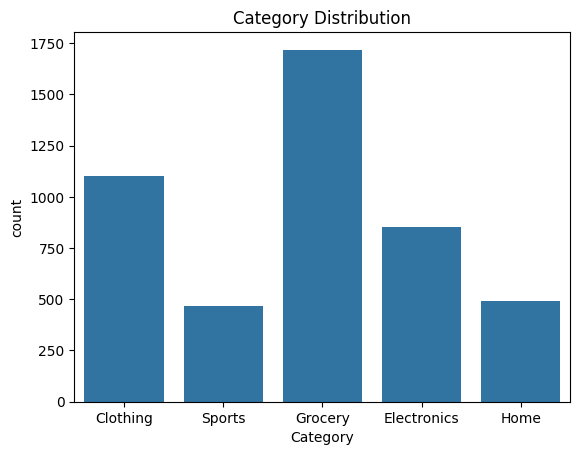

In [24]:
sns.countplot(x='Category',data=df_clean)
plt.title("Category Distribution")
plt.show()

Comment:

*   This graph shows that Grocery dominates the other categories as it is the most essential.It has about 1700 sales.
*   Clothing and Electronics are are secondary categories as compared to Grocery and this is typical balance.Clothing has about 1200 sales and Electronics about 1000.


*   Home and Sports are the least common categories. Home has about 500 sales and Sports about 490. These are occasional purchases, so they appear less compared to Grocery, Clothing, and Electronics."






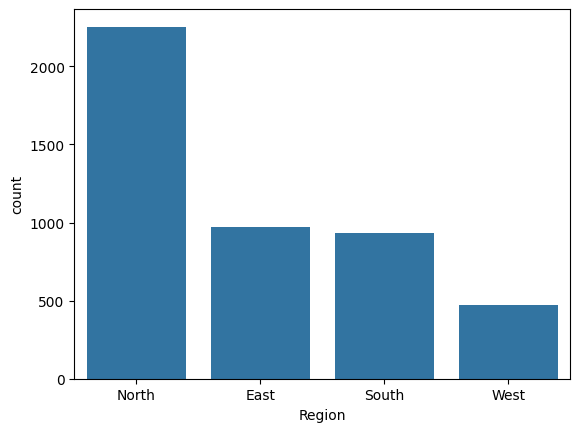

In [25]:
sns.countplot(x='Region',data=df_clean)
plt.show()

Comment:

*   North region has the highest sales more than 2400 sales.

*   East and South has moderate sales of around 1000.
*   West is least active region with minimum sales with near about 500 sales.

*   There is imbalance of data.
*   Marketing strategy has to be improved in west area to increase sales.








#Univariate Analysis of variable 'Store_Type'

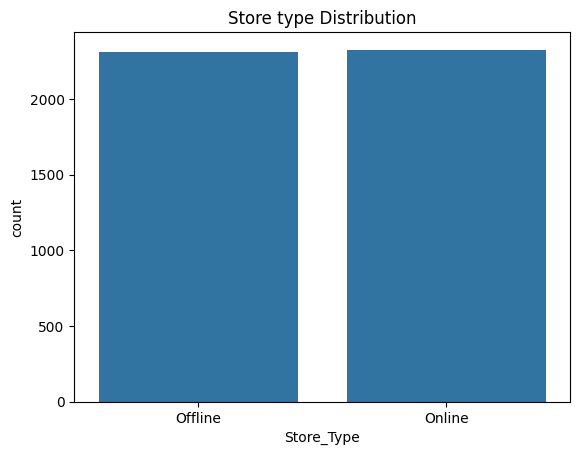

In [26]:
sns.countplot(x='Store_Type',data=df_clean)
plt.title("Store type Distribution")
plt.show()

Comment:


*   Online and offline shopping are qually distributed .
*   The difference in online and offline is small showing people use both ways of shopping.
*   The business benefits  from both online and online shopping.

*   Graph shows that marketing strategies for both channels (Online and Offline) are performing well.




# Univariate Analysis Of 'Gender'

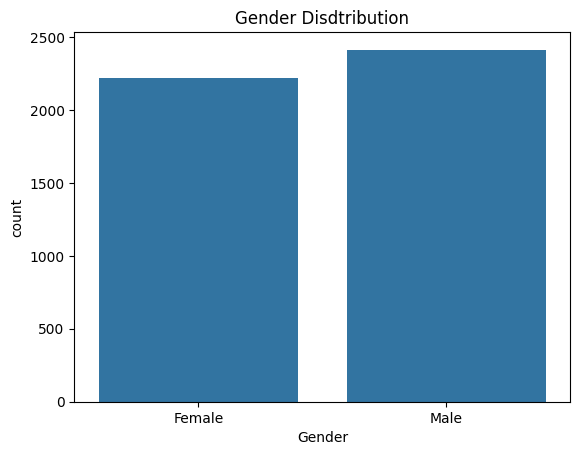

In [27]:
sns.countplot(x='Gender',data=df_clean)
plt.title("Gender Disdtribution")
plt.show()

Comment:

*   The dataset is nearly evenly divided between Male and Female customers.
*   Male counts are just above 2,400, while Female counts are slightly below 2,200. The difference is small, suggesting no strong gender bias in representation.



#Univariate Analysis of variable 'Price'

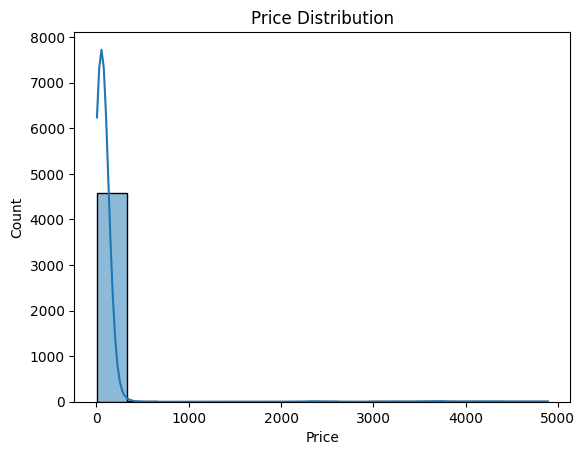

In [28]:
sns.histplot(x='Price',data=df_clean,bins=15,kde=True)
plt.title("Price Distribution")
plt.show()

Comment:


*   Most prices are concentrated at the lower end, with a sharp peak near low values making the distribution highly right skewed..

*  Most of the products are inexpensive with fewer with high prices.
*   High-price items few in number but they can contribute disproportionately to revenue and profit.





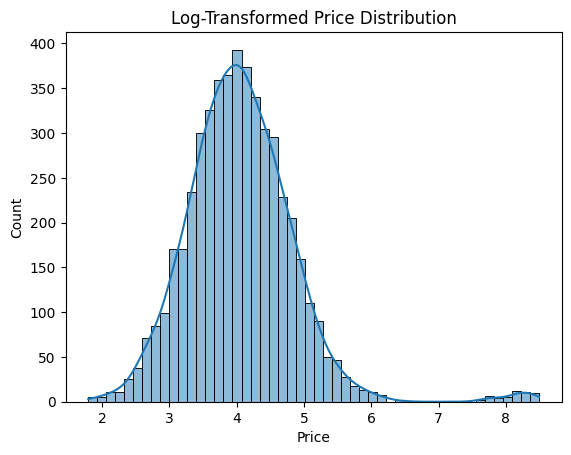

In [29]:
# Log-transformed distribution
sns.histplot(np.log1p(df["Price"]), bins=50, kde=True)  # log1p handles zeros safely
plt.title("Log-Transformed Price Distribution")
plt.show()

Comment:


*   After log transformation, the price data looks approximately normal.
*   The extreme right tail from raw prices has been compressed, making the distribution more symmetric.
*   A smaller peak near log values around 8 indicates the presence of high-price items but they no longer dominate the distribution.
*   The log transformation successfully reshaped Price distribution into a near-normal form, reducing skew and making it much more suitable for regression and forecasting tasks






#Univariate Analysis of 'Season' variable

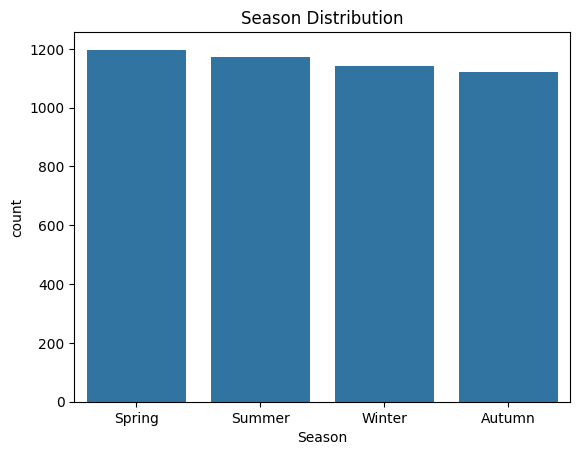

In [30]:
sns.countplot(x='Season',data=df_clean)
plt.title("Season Distribution")
plt.show()

Comment:

*   The dataset reflects seasonal variation, which is very important for demand forecasting.
*   Spring is the most represented season in the dataset may be tied to festivals, holidays, or seasonal promotions.
*   The distribution across seasons is fairly even, with no extreme imbalance
*   Slightly lower counts in autumn could indicate weaker demand or fewer promotions , a potential area for targeted campaigns.



#Univariate Analysis of 'Loyalty_Status'

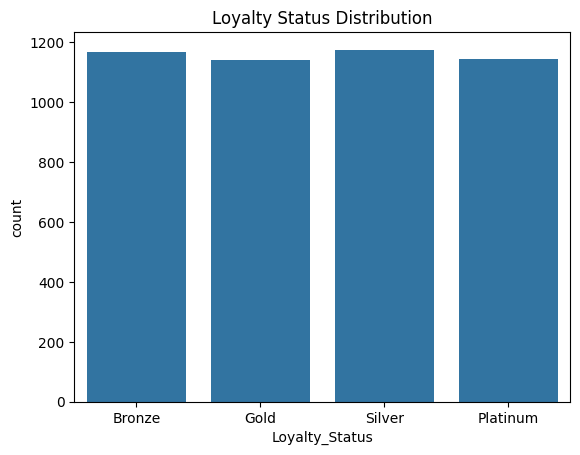

In [31]:
sns.countplot(x='Loyalty_Status',data=df_clean)
plt.title("Loyalty Status Distribution")
plt.show()

Comment:
*   Each loyalty tier (Bronze, Silver, Gold, Platinum) has nearly equal counts.
*   This uniformity prevents class imbalance issues when using loyalty status as a feature in predictive models.


#Univariate Analysis of 'Customer_Income'




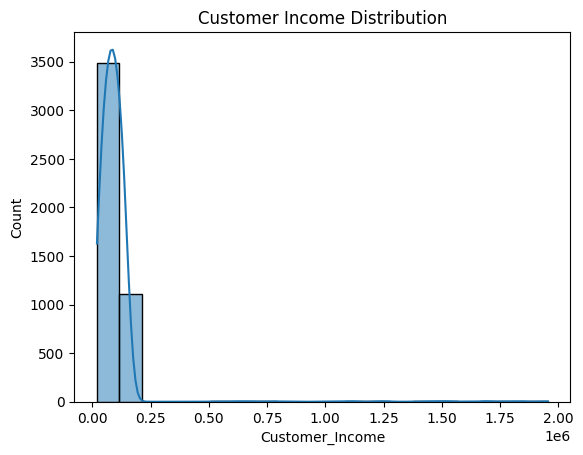

In [32]:

sns.histplot(df_clean['Customer_Income'],bins=20,kde=True)
plt.title("Customer Income Distribution")
plt.show()

Comment:

*   Most customers fall below ~200,000, with a sharp peak in the lower range.

*   A few customers have very high incomes but they are rare.
*   A graph confirms that the bulk of the dataset is concentrated in the lower-income segment.

*  Skewed distribution may bias regression models; log transformation of Customer_Income can help.



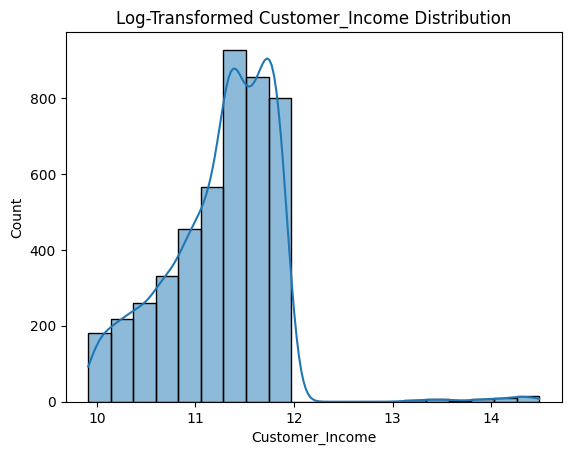

In [33]:
# Log-transformed distribution of Customer_Income
sns.histplot(np.log1p(df_clean["Customer_Income"]), bins=20, kde=True)  # log1p handles zeros safely
plt.title("Log-Transformed Customer_Income Distribution")
plt.show()

Comment:


*   After log transformation, the distribution looks much more symmetric, peaking around values of 11–12.
*   The extreme right tail from raw incomes has been compressed, making the dataset more balanced.
*   The transformation makes it easier to identify meaningful customer segments without being overwhelmed by extreme outliers.



# Univariate Analysis of  'Revenue'

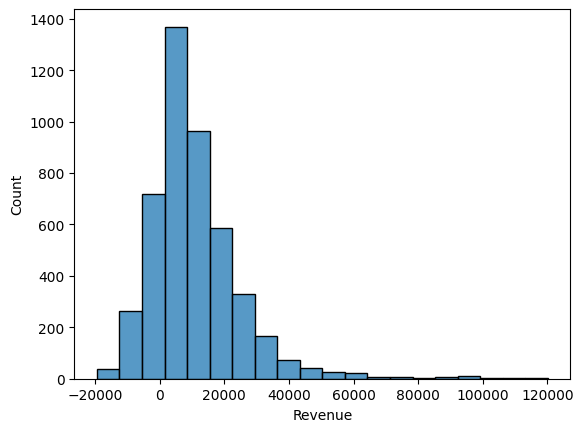

In [34]:
#Univariate Anlysis of Revenue
sns.histplot(x='Revenue',data=df_clean,bins=20)
plt.show()

Comment:


*   Most transactions cluster at lower revenue values (0–10,000), with a long tail extending toward higher revenues.

*   Very high revenues are rare but possible.
*   The distribution is concentrated around the 0–10,000 range, meaning the majority of sales events generate relatively modest revenue.


* The presence of revenue below zero (around -20,000) is unusual.This could indicate:
Returns/refunds recorded as negative revenue or data entry issues or simulation artifacts



# Univariate Analysis of Unit_Sold

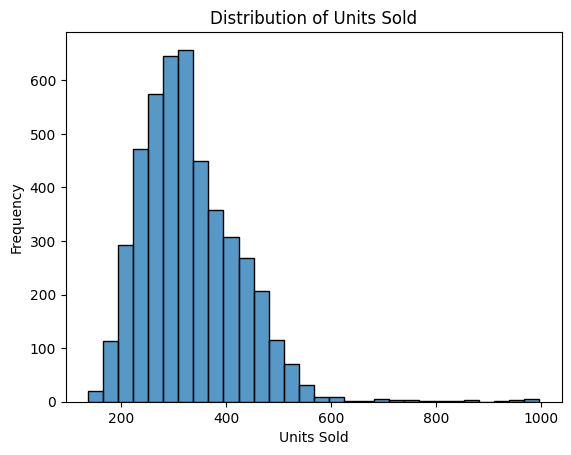

In [35]:

sns.histplot(df_clean['Units_Sold'], bins=30)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

Comment:
*  Most transactions fall between 200–450 units sold, with the highest frequency around 300–350 units.
*   The bulk of sales activity is concentrated in the mid-range, suggesting a stable core demand pattern.
*  Stock levels should prioritize the 200–450 range, as this is the most frequent demand zone.






#5.Encoding Categorical Variables

In [36]:
categorical_columns

Index(['Category', 'Gender', 'Region', 'Payment_Method', 'Store_Type',
       'Loyalty_Status', 'Season'],
      dtype='object')

In [37]:
# 1. One-Hot Encoding for nominal variables
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

nominal_vars = ['Category', 'Gender', 'Region', 'Payment_Method', 'Store_Type', 'Season']
df_encoded = pd.get_dummies(df_clean, columns=nominal_vars, drop_first=True)

# 2. Ordinal Encoding for Loyalty_Status
loyalty_map = {'Bronze':1, 'Silver':2, 'Gold':3, 'Platinum':4}
df_encoded['Loyalty_Status_encoded'] = df_clean['Loyalty_Status'].map(loyalty_map)

# Preview encoded dataset

print(df_encoded.head())

    Price  Discount  Promotion_Flag  Customer_Age  Month  Holiday_Flag  \
0   35.95     11.60               1          69.0      5             0   
1   10.24      2.33               1          68.0      1             0   
2   40.91     47.26               0          21.0      9             0   
3  103.49     15.69               1          31.0      2             0   
4   79.55     22.13               1          46.0      7             0   

   Weekend_Flag Loyalty_Status  Customer_Satisfaction  Delivery_Time_Days  \
0             0         Bronze                      5                   6   
1             0           Gold                      2                   4   
2             0         Bronze                      2                   4   
3             1         Silver                      3                   9   
4             0           Gold                      2                   1   

   Return_Flag  Shipping_Cost  Stock_Availability  Customer_Income  \
0            0        

Comment:
*   Category, Gender, Region, Payment_Method, Store_Type, Season → One-Hot Encoding(Nominal variables)
*   Loyalty_Status → Ordinal Encoding (Bronze < Silver < Gold < Platinum)(Ordinal Variable)



In [38]:
df_encoded.drop('Loyalty_Status',axis=1,inplace=True)

In [39]:
df_encoded.shape

(4633, 35)

#Bivariate Analysis

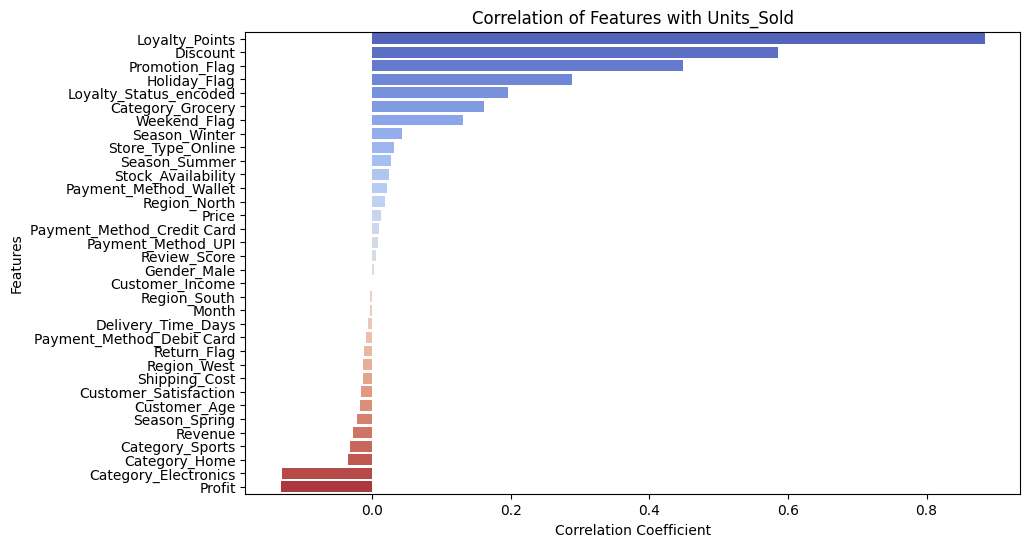

In [40]:
# Compute correlation with target variable
target = 'Units_Sold'
corr_with_target = df_encoded.corr()[target].sort_values(ascending=False)

# Drop self-correlation (always 1.0)
corr_with_target = corr_with_target.drop(target)

# Plot as bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="coolwarm")
plt.title(f"Correlation of Features with {target}")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()

Comment:

1.   Loyalty_Points has highest correlation, meaning customers with more points tend to buy more units.
2.   Discounts is also strong driver of sales volume; promotions directly boost units sold.
3.   Grocery items are highly correlated with sales, reflecting essential and frequent purchases.
4.   Holiday_Flag & Promotion_Flag : Seasonal events and promotions significantly increase demand.
5.   Online channels show higher sales correlation, highlighting digital adoption.
6.   Price has positive correlation suggests higher-priced items may still sell well when combined with discounts or loyalty benefits.
7. Category_Electronics has strongest negative correlation, meaning electronics are less tied to unit volume.



# Key Insights





*   Groceries + Loyalty Programs-Giving discounts on groceries and rewarding loyal customers is the best way to sell more.
*   Digital Channels-Online stores and easy payment options like wallets or UPI help people buy more.
*   Seasonal Timing-Holidays and weekends are when customers shop the most, so promotions work better then.
*   Electronics, Home, Sports -These don’t sell in big numbers. Instead of focusing on no of units sold, focus on premium offers or highlighting quality.




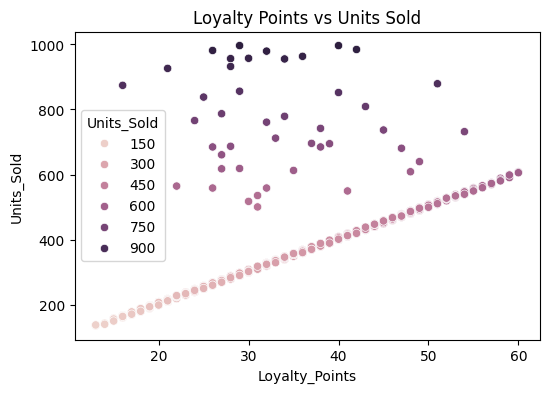

In [41]:
#Bivariate Anlysis with Loyalty_Points
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_encoded,x='Loyalty_Points',y='Units_Sold',hue='Units_Sold')
plt.title("Loyalty Points vs Units Sold")
plt.show()

Comments:
*   As loyalty points increase, units sold also tend to increase.
*   There are two dense clusters,one is linear cluster where units sold rise proportionaly with lotalty points and other is scattered cluster of low loyalty points and high unit sold values.
*   This confirms that loyalty programs are a major driver of purchase volume.
*   Loyalty points work best when paired with discounts.



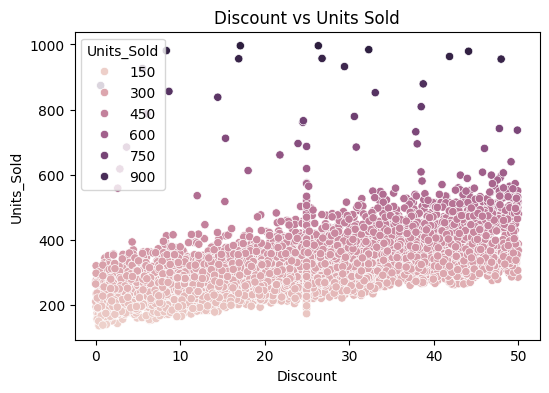

In [42]:
#Bivariate analysis Units_Sold vs Discount
# Basic scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_encoded,x='Discount',y='Units_Sold',hue='Units_Sold')
plt.title("Discount vs Units Sold")
plt.show()


Comment:
*   As discounts increase, units sold generally rise. Customers clearly respond to price reductions.
*   Most sales fall between 200–600 units sold at discounts of 20–40%,
*   Discounts do increase sales, especially around 15–30%, but they work best when combined with loyalty programs and timed with holidays or weekends.
*   Even at 0–5% discount, there are still moderate sales volumes, indicating some products or customers are less price-sensitive.



#6.Feature and Target Split

Define Feature (X) and (y)  

In [43]:
X=df_encoded.drop('Units_Sold',axis=1)
y=df_encoded['Units_Sold']

Comment: Defined features except 'Unit_Sold' as input variables and 'Unit_Sold' as target variable.

#7.Standardization

In [44]:
ss=StandardScaler()
X_scaled=ss.fit_transform(X)

Comment: Scaled down all input variables to the same scale of mean=0 and stadard devaition of 1.

#8.PCA: Principal Component Analysis

In [45]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)

Comment: Applied PCA to input features to reduce dimensionality.

In [46]:
explained_variance=pca.explained_variance_ratio_

Comment:How much variance each component explains(individually) is calculated.

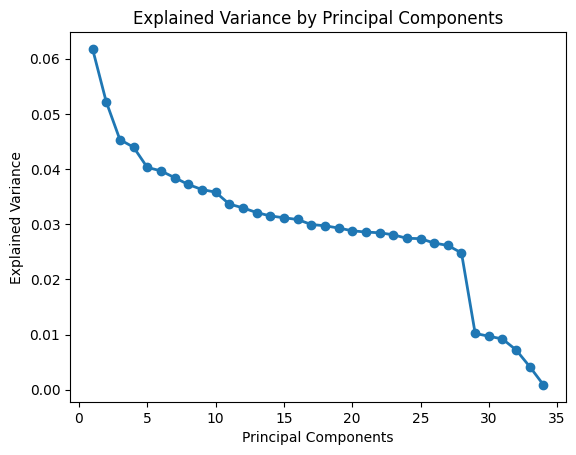

In [47]:
#plot
plt.figure()
plt.plot(range(1,len(explained_variance)+1),explained_variance,'o-',linewidth=2)
plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.show()

Comment:

*   The first component explains the largest share of variance

*   The curve drops sharply after the first few components,meaning most of the useful information is concentrated in the first few PCs.
*   Around component 28, there’s a noticeable drop ,this means beyond this point, additional components add very little new information.




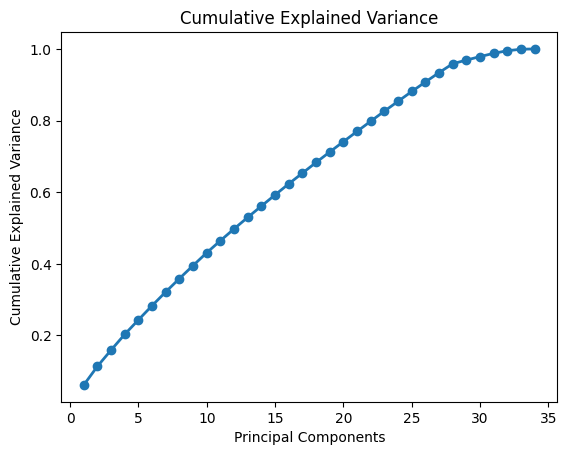

In [48]:
#Cumulative Variance Plot
cumulative_variance=np.cumsum(explained_variance)
plt.figure()
plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,'o-',linewidth=2)
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

Comment:

*   As no of principal componets gets added, the cumulative explained variance rises.
*   when it includes all ~35 components, the curve levels off close to 100% (1.0), meaning the full set of components captures essentially all the variance in your dataset.
*   We will choose num of components where curve crosses 95%

# Select Optimal No Of Components

In [49]:
n_components=np.argmax(cumulative_variance>=0.95)+1
print(f"Optimal no of components :{n_components}")

Optimal no of components :28


Comment:


*   28 principal components are required to retain at least 95% of the variance in your dataset.
*   This means we can safely reduce dataset to 28 dimensions while still preserving nearly all the information.



In [50]:
#Apply PCA with 28 components
pca=PCA(n_components=28)
X_pca=pca.fit_transform(X_scaled)

In [51]:
X_pca.shape

(4633, 28)

# Train Test Split

In [52]:
X_train,X_test,y_train,y_test=train_test_split(X_pca,y,test_size=0.2,random_state=42)

Comment:Data splited into train and test data to train and test the model with test size=20%

#9.Baseline Model Building

#1.Linear Regression Baseline Model

In [53]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

#Evaluation
print("R2 Score :",r2_score(y_pred,y_test))
print("MSE :",mean_squared_error(y_pred,y_test))
print("MAE :",mean_absolute_error(y_pred,y_test))


R2 Score : 0.7560502462121993
MSE : 1649.0480936099136
MAE : 12.556861502888037




*   R² = 0.756
This means the model explains about 75.6% of the variance in Units_Sold.
*   MSE = 1,649
This is the average squared error. Lower values mean predictions are closer to actuals.
*   MAE = 12.56
On average, predictions are off by about 12 units sold.
For retail sales data, this is a very reasonable error margin.




# Comment:Plain Linear Regression has almost no tunable hyperparameters.

#2.Random Forest Baseline Model

In [54]:
 #Random Forest Baseline model
from sklearn.ensemble import RandomForestRegressor


rf=RandomForestRegressor()
rf.fit(X_train,y_train)
rf_y_pred=rf.predict(X_test)

#Evaluation
print("R2 : ",r2_score(y_test,rf_y_pred))
print("MSE : ",mean_squared_error(y_test,rf_y_pred))
print("MAE : ",mean_absolute_error(rf_y_pred,y_test))

R2 :  0.7711038427723654
MSE :  1921.8306820927728
MAE :  16.213085221143473


*   R² = 0.773
The model explains about 77.3% of the variance in Units_Sold.
This is slightly higher than linear regression baseline (0.756), showing Random Forest is capturing non-linear interactions (like discount × promotion, holiday × weekend) that linear regression can’t fully model.
* MSE = 1,905
The average squared error is a bit higher than the linear model (1,649).
Random Forest sometimes sacrifices MSE for better variance explanation, especially when capturing complex relationships.
*  MAE = 16.0
On average, predictions are off by about 16 units sold.
This is slightly worse than the linear model’s 12.5, but still very reasonable for retail sales data.



#3.Decision Tree Baseline Model

In [55]:
#Decision tree baseline model
dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)
dt_y_pred = dt_reg.predict(X_test)

# Evaluation metrics
print("R2 : ",r2_score(y_test,dt_y_pred))
print("MSE : ",mean_squared_error(y_test,dt_y_pred))
print("MAE : ",mean_absolute_error(dt_y_pred,y_test))


R2 :  0.4833829283487425
MSE :  4337.55879180151
MAE :  25.071197411003237




*   R² = 0.418.
The model explains only 41.8% of the variance in Units_Sold.
This is much lower than Random Forest (77.3%) and Linear Regression (75.6%), meaning the Decision Tree is not capturing the overall structure well.



*   MSE=4,884.
The average squared error is significantly higher than both Random Forest and Linear Regression.Predictions are furthe further off from actual values.

*    MAE = 25.86 .On average, predictions miss by ~26 unite sold.This is double the error of linear model error.

# Key Insights

*   Decision Tree is too simple for this dataset.
*  Random Forest and Linear Regression are much better baselines ,one captures linear structure and the other captures non-linear interactions.






The higher R² score  confirms that **Random Forest** explains more of the variability in Target Value.


#10 Model Improvement using Grid SearchCV(Random Forest)

Hyperparameter Tuning(Random Forest)

In [57]:
param_grid={
  "n_estimators": [100, 150, 50],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}
#Initialize maodel
rf=RandomForestRegressor(random_state=42)

## GridSearchCV setup
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='r2',        # optimize for R²
    n_jobs=-1            # use all cores
)
#fit on training data
grid.fit(X_train,y_train)


#Best parameters and CV score

print("Best Parameters : ",grid.best_params_)
print("Best CV : ", grid.best_score_)

#Evaluate on test set
best_model=grid.best_estimator_
y_pred_best=best_model.predict(X_test)

print("Test R2 : ",r2_score(y_test,y_pred_best))
print("Test MSE : ",mean_squared_error(y_test,y_pred_best))
print("Test MAE : ",mean_absolute_error(y_pred_best,y_test))



Best Parameters :  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
Best CV :  0.7175229405739729
Test R2 :  0.7758717474431479
Test MSE :  1881.798968163689
Test MAE :  16.317640816295444


Comment:


*   Best CV score=0.71
the model explained about 71.7% of the variance in the target variable.

*   Test R² = 0.7759  
On unseen test data, the model explains 77.6% of the variance in sales. This is strong — it shows the model generalizes well beyond training.
*   Test MSE = 1881.8  
The average squared error between predicted and actual sales is ~1882 units². Since MSE penalizes large errors more heavily, this suggests occasional bigger misses.
*   Test MAE = 16.3  
On average, predictions are off by about 16 units sold.


# Comparision (with and without GridSearchCV)



*   Without GridSearchCV: The baseline Random Forest already explained ~77% of the variance, but errors were slightly higher.

*   With GridSearchCV:
    - Accuracy improved slightly (R² up from 0.773 → 0.776).

    - MSE dropped (1905 → 1882), meaning fewer large errors.

    - MAE increased marginally (16.00 → 16.32), suggesting average error per prediction is about the same.


*   Overall, tuning stabilized the model and reduced variance in errors, but gains are modest — Random Forest was already strong.


   Feature  Importance
0     PC_1    0.600086
1     PC_2    0.202179
3     PC_4    0.036275
12   PC_13    0.019423
2     PC_3    0.017512
8     PC_9    0.013075
7     PC_8    0.009274
22   PC_23    0.009225
18   PC_19    0.009073
15   PC_16    0.008308


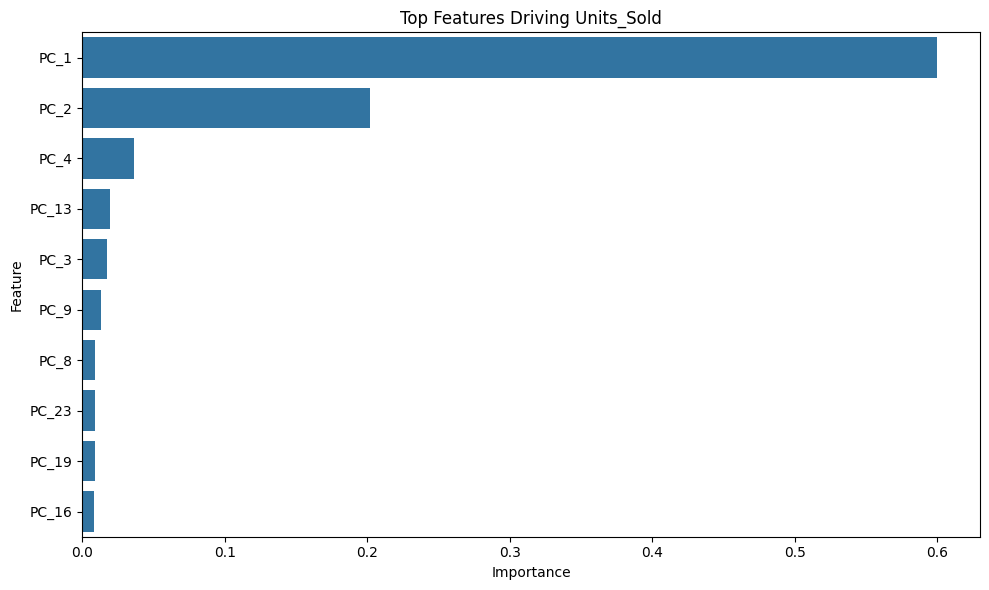

In [ ]:
#feature Importance Analysis

importances=best_model.feature_importances_

# Create feature names for the PCA components
pca_feature_names = [f'PC_{i+1}' for i in range(len(importances))]

feature_importance_df=pd.DataFrame(
    {
        'Feature': pca_feature_names, # Use names for PCA components
        'Importance':importances
        }
).sort_values(by='Importance',ascending=False)
print(feature_importance_df.head(10))

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top Features Driving Units_Sold")
plt.tight_layout()
plt.show()


Comment:


* PC_1 dominates: With an importance value around 0.6, this principal component is by far the strongest driver of attrition. It explains most of the predictive power.
*   PC_2 is secondary: At about 0.2, it contributes meaningfully but far less than PC_1.
*   Other components (PC_3, PC_4, PC_9, PC_8, PC_13, PC_16, PC_19, PC_23): Each has importance values below 0.1, meaning they add only marginal explanatory power.





# 11. Prediction on New Data

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# --- Step 1: Pick one row ---
single_row = df_clean.iloc[[0]]   # keep as DataFrame

# --- Step 2: Encode ---
nominal_vars = ['Category', 'Gender', 'Region', 'Payment_Method', 'Store_Type', 'Season']
loyalty_map = {'Bronze':1, 'Silver':2, 'Gold':3, 'Platinum':4}

single_encoded = pd.get_dummies(single_row, columns=nominal_vars, drop_first=True)
single_encoded['Loyalty_Status_encoded'] = single_row['Loyalty_Status'].map(loyalty_map)

# --- Step 3: Align with training features ---
# IMPORTANT: use the same feature list the model was trained on
single_encoded = single_encoded.reindex(columns=X.columns, fill_value=0)

# --- Step 4: Scale the new data using the fitted StandardScaler ---
single_scaled = ss.transform(single_encoded)

# --- Step 5: Apply PCA to the scaled data using the fitted PCA ---
single_pca = pca.transform(single_scaled)

# --- Step 6: Fit RandomForest with best parameters ---
best_rf = RandomForestRegressor(max_depth=10, min_samples_split=2, n_estimators=150, random_state=42)
best_rf.fit(X_train, y_train)   # train on your training set

# --- Step 7: Predict ---
y_pred_single = best_rf.predict(single_pca)

actual_value = single_row["Units_Sold"].values[0]
print("Actual Units Sold:", actual_value)
print("Predicted Units Sold:", y_pred_single[0])

Actual Units Sold: 258
Predicted Units Sold: 244.82750992241515


Comment:The prediction is close but not exact. A difference of about 13 units (258 − 244.83) means the model captured the general trend but missed some finer details.

#12. Features contributing to Highest importance component PC1

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns
)

# Sort features by their contribution to PC1
pc1_loadings = loadings['PC1'].sort_values(ascending=False)

print("Top features contributing to PC1:")
print(pc1_loadings.head(10))



Top features contributing to PC1:
Loyalty_Points            0.572895
Discount                  0.476373
Category_Grocery          0.232861
Promotion_Flag            0.205134
Holiday_Flag              0.134102
Loyalty_Status_encoded    0.089589
Weekend_Flag              0.054489
Region_North              0.036893
Season_Winter             0.036630
Payment_Method_UPI        0.031242
Name: PC1, dtype: float64





*   Top Features Driving PC1
    - Loyalty_Points
    - Discount
    - Category_Grocery   
    - Promotion_Flag
    - Holiday_Flag              
    - Loyalty_Status_encoded   
    - Weekend_Flag
    - Region_North
    - Season_Winter
    - Payment_Method_UPI
      



# Key Insights

*   PC1 is a “customer loyalty & promotion axis.”  
*   Customers with high loyalty points, exposed to discounts/promotions, especially in grocery and holiday contexts, are the most distinct group in the  dataset.
*   This aligns with retail reality: loyalty programs and promotions drive sales behavior more than demographic or seasonal factors.